In [18]:
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
from langgraph.graph import START,END, StateGraph
from langchain_groq import ChatGroq
from pydantic import BaseModel
from langchain_core.prompts import PromptTemplate


In [20]:
class postState(BaseModel):
    topic: str
    insta: str
    twitter: str
    linkedin: str
    

In [21]:
llm = ChatGroq(
    model="openai/gpt-oss-20b"
)

In [26]:
def instaPost(state: postState):
    topic = state.topic
    
    prompt = f"write an Instagram post about {topic}. Keep the tone casual and engaging."

    
    res = llm.invoke(prompt).content
    
    return {"insta": res}

def twitterPost(state: postState):
    topic = state.topic
    
    prompt = f"Write a Twitter post about {topic}. Keep the tone quick"

    
    res = llm.invoke(prompt).content
    
    return {"twitter": res}

def linkedinPost(state: postState):
    topic = state.topic
    
    prompt = f"Write a LinkedIn post about {topic}. Keep the tone professional and informative."

    
    res = llm.invoke(prompt).content
    
    return {"linkedin": res}

In [27]:
graph = StateGraph(postState)

graph.add_node("instaPost",instaPost)
graph.add_node("twitterPost",twitterPost)
graph.add_node("linkedinPost",linkedinPost)

graph.add_edge(START,"instaPost")
graph.add_edge(START,"twitterPost")
graph.add_edge(START,"linkedinPost")
graph.add_edge("instaPost",END)
graph.add_edge("twitterPost",END)
graph.add_edge("linkedinPost",END)

graph = graph.compile()


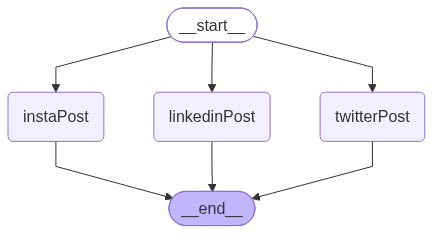

In [28]:
graph

In [29]:
graph.invoke({
    "topic": "Importance Of AI",
    "insta": "",
    "twitter": "",
    "linkedin": ""
})

{'topic': 'Importance Of AI',
 'insta': '🚀✨ **Why AI is the real MVP of our time** ✨🚀\n\nHey fam! 👋 Ever wonder why AI is popping up in your feed, your playlist, and even your coffee order? ☕️🤖 It’s not just tech hype—AI is the secret sauce that’s making life smoother, smarter, and a whole lot more fun.\n\n1️⃣ **Problem‑solving on steroids** – From predicting traffic jams to diagnosing diseases, AI turns data into decisions faster than a blink.  \n2️⃣ **Personalized vibes** – Your music, your shopping, your news—AI curates it all so you get exactly what you love (and sometimes what you didn’t even know you needed).  \n3️⃣ **Creativity unleashed** – Artists, writers, designers—AI tools help you experiment, iterate, and push boundaries.  \n4️⃣ **Sustainability game‑changer** – Optimizing energy use, reducing waste, and even helping us grow crops smarter. 🌱💡\n\nBottom line: AI isn’t just a tool; it’s a partner that’s reshaping how we work, play, and solve the world’s toughest problems. 🌍💪